<a href="https://colab.research.google.com/github/amypongpong/Jurkat-Cell-Cycle-Classification/blob/main/Jurkat%20Cell%20Cycle%20Classification" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Quality & Annotation Error Effects on CNN Cell-Cycle Classification
### BBBC048 — Jurkat Cell Cycle Dataset

This notebook implements a controlled study of how image degradation and annotation error affect
a CNN trained to classify Jurkat cell-cycle phase:

> **Design.** A single CNN architecture is trained under four data conditions, each repeated across
> multiple random seeds:
> 1. **Clean images, correct labels** (baseline)
> 2. **Degraded images, correct labels** (isolates image-quality effect)
> 3. **Clean images, noisy labels** (isolates annotation-error effect)
> 4. **Degraded images, noisy labels** (combined effect — the condition studied in earlier drafts)
>
> All four conditions are evaluated on the **same held-out, clean, correctly-labeled test set**,
> built once and shared across every condition and seed. Reporting mean ± standard deviation across
> seeds, rather than a single run, lets us say whether an observed difference is a real effect or
> noise.

**Why this version differs from earlier drafts.** Two earlier issues are fixed here in addition to
the ground-truth label parsing bug fixed previously:
- **Data leakage**: BBBC048 captures each physical cell across multiple imaging channels, and the
  ground-truth file has one row per channel image. Earlier versions of this notebook treated every
  channel row as an independent example, which meant different channel images of the *same* cell
  could end up on both sides of the train/test split. This notebook deduplicates to exactly one
  image per physical cell before splitting, so no cell's channel images can appear in both sets.
- **Wasteful class balancing**: earlier versions forced every class to contribute an equal, small
  number of images (capped by the rarest class), throwing away the vast majority of the abundant
  interphase classes. This version keeps far more of the available data per class (up to a
  configurable cap) and uses **class-weighted training** to handle the remaining imbalance instead.

**How to use this notebook**
1. Run cells top to bottom in Google Colab (`Runtime > Run all` works, but the first time through you
   should run the *Inspect downloaded data* cells one at a time — BBBC048's internal file layout can
   vary and you may need to tweak the parsing cell marked ⚠️.)
2. `Runtime > Change runtime type > GPU (T4)` is strongly recommended — training is much faster.
3. **Compute note**: this notebook trains 4 conditions × `len(CONFIG["seeds"])` seeds = up to 12
   full models. With the default config this can take a couple of hours on a T4. To sanity-check the
   pipeline first, temporarily set `CONFIG["seeds"] = [42]` (1 seed → 4 runs) before doing a full
   multi-seed run for your final numbers.

**Citation**: Eulenberg, P., Köhler, N., Blasi, T. *et al.* "Reconstructing cell cycle and disease
progression using deep learning." *Nat Commun* 8, 463 (2017). Dataset: BBBC048, Broad Bioimage
Benchmark Collection (Ljosa et al., *Nature Methods*, 2012), CC BY-NC-SA 3.0, courtesy of Andrew Filby,
Newcastle University.


## 0. Setup

In [1]:
# Core imports
!pip install -q tifffile

import os, io, glob, zipfile, random, json, math, re, tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Download the BBBC048 dataset

Source: [Broad Bioimage Benchmark Collection — BBBC048](https://bbbc.broadinstitute.org/BBBC048)

- Images: `BBBC048v1.zip` (~1.5 GB, 32,266 single-cell images)
- Labels: `Ground_truth.lst` (cell phase per image: G1, S, G2, Prophase, Metaphase, Anaphase, Telophase)

> ⏱️ The zip is large — downloading + unzipping can take several minutes on Colab.


In [2]:
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

ZIP_URL = "https://data.broadinstitute.org/bbbc/BBBC048/BBBC048v1.zip"
GT_URL  = "https://data.broadinstitute.org/bbbc/BBBC048/Ground_truth.lst"

zip_path = os.path.join(DATA_DIR, "BBBC048v1.zip")
gt_path  = os.path.join(DATA_DIR, "Ground_truth.lst")

if not os.path.exists(zip_path):
    !wget -q --show-progress -O "{zip_path}" "{ZIP_URL}"
else:
    print("Zip already downloaded.")

if not os.path.exists(gt_path):
    !wget -q -O "{gt_path}" "{GT_URL}"
else:
    print("Ground truth already downloaded.")

print("Zip size (MB):", round(os.path.getsize(zip_path) / 1e6, 1))


/content/data/BBBC0 100%[===================>]   1.50G  13.5MB/s    in 59s     
Zip size (MB): 1611.4


In [3]:
IMAGES_DIR = os.path.join(DATA_DIR, "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

# Only unzip once (this can take a few minutes the first time)
if not os.listdir(IMAGES_DIR):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(IMAGES_DIR)
    print("Extraction complete.")
else:
    print("Images already extracted.")

# Count extracted files
all_files = glob.glob(os.path.join(IMAGES_DIR, "**", "*.*"), recursive=True)
print("Total extracted files:", len(all_files))
print("Example paths:")
for p in all_files[:10]:
    print(" ", p)


Extraction complete.
Total extracted files: 7
Example paths:
  /content/data/images/final.tar.gz
  /content/data/images/CellCycle.zip
  /content/data/images/predictions.tar.gz
  /content/data/images/CellCycle.mp4
  /content/data/images/1540408813.tar.gz
  /content/data/images/CCS_final_evaluation_scripts.tar.gz
  /content/data/images/scRNA.tar.gz


In [4]:
# BBBC048v1.zip's top level often contains *sub-archives* rather than raw images
# (e.g. CellCycle.zip, scRNA.tar.gz, predictions.tar.gz, evaluation scripts...).
# We only want the images, so we recursively extract nested .zip/.tar/.tar.gz files
# and then search specifically for image files among the results.
import tarfile

IMAGE_EXTS = (".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp")

def is_archive(path):
    return path.lower().endswith((".zip", ".tar.gz", ".tgz", ".tar"))

def extract_archive(path, dest):
    os.makedirs(dest, exist_ok=True)
    try:
        if path.lower().endswith(".zip"):
            with zipfile.ZipFile(path, 'r') as zf:
                zf.extractall(dest)
        elif path.lower().endswith((".tar.gz", ".tgz")):
            with tarfile.open(path, 'r:gz') as tf:
                tf.extractall(dest)
        elif path.lower().endswith(".tar"):
            with tarfile.open(path, 'r') as tf:
                tf.extractall(dest)
        return True
    except Exception as e:
        print(f"  Failed to extract {os.path.basename(path)}: {e}")
        return False

# Prioritize anything with "cellcycle" in the name (this study's actual image data);
# skip large unrelated bundles like scRNA / prediction / evaluation-script archives
# unless nothing else yields images.
top_level_archives = [p for p in all_files if is_archive(p)]
priority = [p for p in top_level_archives if "cellcycle" in os.path.basename(p).lower()]
others = [p for p in top_level_archives if p not in priority]
ordered_archives = priority + others

extracted_any_images = False
for archive_path in ordered_archives:
    dest = archive_path + "_extracted"
    print(f"Extracting {os.path.basename(archive_path)} ...")
    if extract_archive(archive_path, dest):
        found = glob.glob(os.path.join(dest, "**", "*.*"), recursive=True)
        n_images = sum(1 for p in found if p.lower().endswith(IMAGE_EXTS))
        print(f"  -> {len(found)} files, {n_images} look like images.")
        if n_images > 100:
            extracted_any_images = True
            print(f"  Found a promising image source in {os.path.basename(archive_path)} — stopping here.")
            break  # good enough — avoid extracting the other, likely-unrelated, large archives

# Refresh the master file list to include everything extracted so far (recursively,
# in case of a second layer of nested archives)
changed = True
seen_archives = set()
while changed:
    changed = False
    all_files = glob.glob(os.path.join(IMAGES_DIR, "**", "*.*"), recursive=True)
    for p in all_files:
        if is_archive(p) and p not in seen_archives:
            dest = p + "_extracted"
            if not os.path.isdir(dest):
                extract_archive(p, dest)
                seen_archives.add(p)
                changed = True

all_files = glob.glob(os.path.join(IMAGES_DIR, "**", "*.*"), recursive=True)
image_files = [p for p in all_files if p.lower().endswith(IMAGE_EXTS)]

print(f"\nTotal files after recursive extraction: {len(all_files)}")
print(f"Image-like files found: {len(image_files)}")
print("Sample image paths:")
for p in image_files[:10]:
    print(" ", p)

if len(image_files) < 100:
    print("\n⚠️ Still very few images found. Print `[os.path.basename(p) for p in all_files][:30]` "
          "below to see what's actually there, and/or manually extract the remaining archives "
          "(1640408813.tar.gz, final.tar.gz) by adding: extract_archive(<path>, <path>+'_extracted')")


Extracting CellCycle.zip ...
  -> 129067 files, 129064 look like images.
  Found a promising image source in CellCycle.zip — stopping here.


/tmp/ipykernel_1003/1747891340.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(dest)



Total files after recursive extraction: 129616
Image-like files found: 129064
Sample image paths:
  /content/data/images/CellCycle.zip_extracted/CellCycle/Prophase/34199_Ch6.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/Prophase/21254_Ch3.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/Prophase/23344_Ch6.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/Prophase/24142_Ch4.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/Prophase/35375_Ch3.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/Prophase/44696_merged.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/Prophase/42966_Ch3.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/Prophase/586_Ch6.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/Prophase/9586_Ch3.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/Prophase/38736_Ch4.ome.jpg


## 2. Inspect the downloaded data ⚠️

BBBC048 images come from an ImageStream imaging flow cytometer, so each cell may be represented by
**multiple channel images** (e.g. brightfield + fluorescence channels) and the exact file naming
convention / `Ground_truth.lst` format can vary by release. **Run the two cells below first and look at
the printed output** — then adjust the parsing cell in Section 3 if needed (e.g. the separator, column
order, or how channel number is encoded in the filename).


In [5]:
# Look at raw content of Ground_truth.lst
with open(gt_path, "r", errors="replace") as f:
    gt_lines = f.readlines()

print("Number of lines in Ground_truth.lst:", len(gt_lines))
print("First 10 lines:")
for line in gt_lines[:10]:
    print(repr(line))


Number of lines in Ground_truth.lst: 96798
First 10 lines:
'19\t0\t./Anaphase/12432_Ch3.ome.jpg\n'
'8\t0\t./Anaphase/12432_Ch4.ome.jpg\n'
'35\t0\t./Anaphase/12432_Ch6.ome.jpg\n'
'36\t0\t./Anaphase/22004_Ch3.ome.jpg\n'
'1\t0\t./Anaphase/22004_Ch4.ome.jpg\n'
'42\t0\t./Anaphase/22004_Ch6.ome.jpg\n'
'23\t0\t./Anaphase/26511_Ch3.ome.jpg\n'
'44\t0\t./Anaphase/26511_Ch4.ome.jpg\n'
'32\t0\t./Anaphase/26511_Ch6.ome.jpg\n'
'34\t0\t./Anaphase/29554_Ch3.ome.jpg\n'


In [6]:
# Look at file extensions / naming patterns actually present among the IMAGE files
# (image_files was built in Section 1 after recursively unpacking nested archives)
exts = pd.Series([os.path.splitext(p)[1].lower() for p in image_files]).value_counts()
print("Image file extensions found:\n", exts)

# Show a handful of filenames to infer the naming convention
basenames = [os.path.basename(p) for p in image_files]
print("\nSample image filenames:")
for b in basenames[:20]:
    print(" ", b)
print(f"\nTotal image files available for matching: {len(image_files)}")


Image file extensions found:
 .jpg    129064
Name: count, dtype: int64

Sample image filenames:
  34199_Ch6.ome.jpg
  21254_Ch3.ome.jpg
  23344_Ch6.ome.jpg
  24142_Ch4.ome.jpg
  35375_Ch3.ome.jpg
  44696_merged.jpg
  42966_Ch3.ome.jpg
  586_Ch6.ome.jpg
  9586_Ch3.ome.jpg
  38736_Ch4.ome.jpg
  44518_Ch4.ome.jpg
  45704_Ch4.ome.jpg
  40938_merged.jpg
  32014_Ch6.ome.jpg
  31177_Ch3.ome.jpg
  15365_Ch4.ome.jpg
  29684_Ch3.ome.jpg
  29937_Ch6.ome.jpg
  16891_merged.jpg
  45168_Ch3.ome.jpg

Total image files available for matching: 129064


## 3. Parse labels and match to image files ⚠️

The cell below tries a few common delimiters automatically. **If the printed class distribution at the
end looks wrong (e.g. only 1 class, or counts don't resemble ~32k total), open `Ground_truth.lst` in
the file browser on the left and adjust `SEP` / `FNAME_COL` / `LABEL_COL` below manually.**


In [7]:
CLASS_NAMES = ["G1", "S", "G2", "Prophase", "Metaphase", "Anaphase", "Telophase"]

def try_parse_ground_truth(path):
    for sep in ["\t", ",", None]:  # None = any whitespace
        try:
            df = pd.read_csv(path, sep=sep, engine="python", header=None)
            if df.shape[1] >= 2:
                return df, sep
        except Exception:
            continue
    raise ValueError("Could not auto-parse Ground_truth.lst — inspect it manually and adjust this cell.")

gt_df, used_sep = try_parse_ground_truth(gt_path)
print("Parsed with separator:", repr(used_sep))
print(gt_df.head())

# Column layout: col 0 = arbitrary per-row index, col 1 = a per-row code that is NOT a
# reliable global class label, col 2 = filepath whose *folder name* is the real,
# unambiguous class label (e.g. "./Anaphase/12432_Ch3.ome.jpg" -> "Anaphase").
# FIX: use the filepath column (not column 0) and pull the label straight from its
# folder name instead of fuzzy-matching the whole path. Fuzzy substring matching on a
# short name like "S" was matching inside "Anaphase"/"Metaphase"/"Prophase"/"Telophase"
# (which all contain the letter "s"), silently collapsing 4 of 7 classes into "S".
PATH_COL = gt_df.shape[1] - 1  # filepath column

gt_df = gt_df.rename(columns={PATH_COL: "filepath_raw"})
gt_df["filepath_raw"] = gt_df["filepath_raw"].astype(str).str.strip()

# file_key = basename of the path -> matches actual image filenames directly
gt_df["file_key"] = gt_df["filepath_raw"].apply(lambda p: os.path.basename(p))

# label_raw = folder name in the path (the true class name, exact, no fuzzy matching)
gt_df["label_raw"] = gt_df["filepath_raw"].apply(lambda p: p.strip("./").split("/")[0])

print("\nUnique raw label values found:")
print(gt_df["label_raw"].value_counts())


Parsed with separator: '\t'
    0  1                             2
0  19  0  ./Anaphase/12432_Ch3.ome.jpg
1   8  0  ./Anaphase/12432_Ch4.ome.jpg
2  35  0  ./Anaphase/12432_Ch6.ome.jpg
3  36  0  ./Anaphase/22004_Ch3.ome.jpg
4   1  0  ./Anaphase/22004_Ch4.ome.jpg

Unique raw label values found:
label_raw
G1           42999
S            25848
G2           25803
Prophase      1818
Metaphase      204
Telophase       81
Anaphase        45
Name: count, dtype: int64


In [8]:
# label_raw values are now exact folder names pulled straight from the path, so they
# already match CLASS_NAMES (case aside). Map through a small case-insensitive dict for
# safety, but no more substring fuzzy-matching — that's what caused the "S" bug.
code_to_name = {c.lower(): c for c in CLASS_NAMES}
gt_df["label"] = gt_df["label_raw"].str.lower().map(code_to_name)

print(gt_df["label"].value_counts())
print("\nUnmapped labels (fix `code_to_name` above if this is non-empty):",
      sorted(set(gt_df["label"].dropna().unique()) - set(CLASS_NAMES)))


label
G1           42999
S            25848
G2           25803
Prophase      1818
Metaphase      204
Telophase       81
Anaphase        45
Name: count, dtype: int64

Unmapped labels (fix `code_to_name` above if this is non-empty): []


In [9]:
# --- Matching strategy (fast version) ---
path_lookup = {}
for p in image_files:
    base = os.path.basename(p)
    stem = os.path.splitext(base)[0]
    path_lookup.setdefault(stem, []).append(p)
    path_lookup.setdefault(base, []).append(p)

gt_df["filepath"] = gt_df["file_key"].map(lambda k: path_lookup.get(k, [None])[0])
n_exact = gt_df["filepath"].notna().sum()
print(f"Exact matching: {n_exact} / {len(gt_df)} matched.")

# --- Fallback: numeric-ID matching (also O(n), no nested scanning) ---
if n_exact < 0.5 * len(gt_df):
    print("Exact matching found too few matches — falling back to numeric-ID matching.")

    def extract_id(s):
        m = re.search(r'\d+', str(s))
        return str(int(m.group())) if m else None

    id_to_paths = {}
    for p in image_files:
        fid = extract_id(os.path.basename(p))
        if fid is not None:
            id_to_paths.setdefault(fid, []).append(p)

    gt_df["file_id"] = gt_df["file_key"].apply(extract_id)
    gt_df["filepath"] = gt_df["file_id"].map(lambda fid: id_to_paths.get(fid, [None])[0])

    n_id = gt_df["filepath"].notna().sum()
    print(f"Numeric-ID matching: {n_id} / {len(gt_df)} matched.")

matched = gt_df.dropna(subset=["filepath"])
print(f"\nFinal matched: {len(matched)} / {len(gt_df)} ground-truth entries.")
print(matched["label"].value_counts())

dataset_df = matched[matched["label"].isin(CLASS_NAMES)].reset_index(drop=True)
print("\nFinal usable dataset size:", len(dataset_df))

Exact matching: 96798 / 96798 matched.

Final matched: 96798 / 96798 ground-truth entries.
label
G1           42999
S            25848
G2           25803
Prophase      1818
Metaphase      204
Telophase       81
Anaphase        45
Name: count, dtype: int64

Final usable dataset size: 96798


In [10]:
# --- DIAGNOSTICS (only needed if the match count above looks wrong) ---
print("gt_df sample:")
print(gt_df.head(10).to_string())
print()
print("Sample file_key values:", gt_df["file_key"].head(10).tolist())
print()
print("Sample actual filenames on disk:", [os.path.basename(p) for p in image_files[:10]])


gt_df sample:
    0  1                  filepath_raw           file_key label_raw     label                                                                           filepath
0  19  0  ./Anaphase/12432_Ch3.ome.jpg  12432_Ch3.ome.jpg  Anaphase  Anaphase  /content/data/images/CellCycle.zip_extracted/CellCycle/Anaphase/12432_Ch3.ome.jpg
1   8  0  ./Anaphase/12432_Ch4.ome.jpg  12432_Ch4.ome.jpg  Anaphase  Anaphase  /content/data/images/CellCycle.zip_extracted/CellCycle/Anaphase/12432_Ch4.ome.jpg
2  35  0  ./Anaphase/12432_Ch6.ome.jpg  12432_Ch6.ome.jpg  Anaphase  Anaphase  /content/data/images/CellCycle.zip_extracted/CellCycle/Anaphase/12432_Ch6.ome.jpg
3  36  0  ./Anaphase/22004_Ch3.ome.jpg  22004_Ch3.ome.jpg  Anaphase  Anaphase  /content/data/images/CellCycle.zip_extracted/CellCycle/Anaphase/22004_Ch3.ome.jpg
4   1  0  ./Anaphase/22004_Ch4.ome.jpg  22004_Ch4.ome.jpg  Anaphase  Anaphase  /content/data/images/CellCycle.zip_extracted/CellCycle/Anaphase/22004_Ch4.ome.jpg
5  42  0  ./Anaphase

## 4. Deduplicate to one image per cell ⚠️

BBBC048 captures each physical cell across multiple imaging channels (this release has three:
`Ch3`, `Ch4`, `Ch6`), and `Ground_truth.lst` repeats the same label once per channel image — so the
96,798 matched rows from Section 3 correspond to only 32,266 *unique* cells (96,798 / 3), matching
the dataset's documented size.

Training on every channel row as if it were an independent example is a problem for two reasons:
1. **Data leakage.** If the train/test split is done on channel rows rather than cells, different
   channel images of the *same* cell can land on both sides of the split — the model could partly
   learn to recognize a specific cell rather than the phase itself, inflating test performance.
2. **Undifferentiated channels.** Without documentation mapping `Ch3`/`Ch4`/`Ch6` to a specific
   imaging modality (brightfield, darkfield, or a fluorescence stain) in this pipeline, blending all
   three together as if they were equivalent grayscale images mixes channels that may carry very
   different amounts of cell-cycle signal.

We address both by keeping exactly **one, consistently-chosen** image per physical cell. The cell
identifier is extracted from the filename, and for every cell we deterministically keep its lowest
channel number (e.g. `Ch3` over `Ch4`/`Ch6` when available), so every retained image comes from the
same channel type wherever possible.


In [11]:
def extract_cell_id(filename):
    """Pull the numeric cell ID that prefixes every BBBC048 filename, e.g. '12432' from
    '12432_Ch3.ome.jpg'."""
    m = re.search(r'(\d+)_', os.path.basename(filename))
    return m.group(1) if m else None

def extract_channel(filename):
    """Pull the channel/variant token, e.g. 'Ch3', 'Ch4', 'Ch6', or 'merged'."""
    m = re.search(r'_(Ch\d+|merged)\.', os.path.basename(filename))
    return m.group(1) if m else "zzz_unknown"

dataset_df["cell_id"] = dataset_df["filepath"].apply(extract_cell_id)
dataset_df["channel"] = dataset_df["filepath"].apply(extract_channel)

n_before = len(dataset_df)

# Deterministic tie-break: sort by channel name (Ch3 < Ch4 < Ch6 alphabetically) so the
# same channel is preferred for every cell where it's available, then keep one row/cell.
dataset_df = dataset_df.sort_values(["cell_id", "channel"])
dataset_df = dataset_df.drop_duplicates(subset="cell_id", keep="first").reset_index(drop=True)

print(f"Deduplicated {n_before} channel-image rows -> {len(dataset_df)} unique cells "
      f"({n_before / max(len(dataset_df), 1):.2f}x reduction, expected ~3x).")
print("\nClass counts after deduplication:")
print(dataset_df["label"].value_counts())
print("\nChannel actually used per cell (should be dominated by a single value):")
print(dataset_df["channel"].value_counts())


Deduplicated 96798 channel-image rows -> 32266 unique cells (3.00x reduction, expected ~3x).

Class counts after deduplication:
label
G1           14333
S             8616
G2            8601
Prophase       606
Metaphase       68
Telophase       27
Anaphase        15
Name: count, dtype: int64

Channel actually used per cell (should be dominated by a single value):
channel
Ch3    32266
Name: count, dtype: int64


## 5. Configuration

Two things changed here from earlier drafts:
- Instead of forcing every class to contribute an equal (and therefore tiny) number of images, we
  keep **up to `max_train_per_class`** images per class — all of a rare class's images if it has
  fewer than the cap, and a random sample of the cap otherwise — and let **class-weighted training**
  (Section 10) handle the remaining imbalance. This uses far more of the available data for the
  common interphase classes than a forced-equal split would.
- `CONDITIONS` defines the 2×2 design (image quality × label quality), and `CONFIG["seeds"]` controls
  how many independent repeats each condition gets. Increase `seeds` for tighter error bars once
  you've confirmed the pipeline runs end-to-end.


In [12]:
CONFIG = {
    "img_size": 64,              # images resized to img_size x img_size
    "test_frac": 0.10,           # fraction of each class reserved for the shared test set
    "min_test_per_class": 5,     # floor on test examples per class, availability permitting
    "max_train_per_class": 2000, # cap per class in the training pool; classes smaller than this
                                  # keep everything they have (no artificial equal-sizing)
    "batch_size": 32,
    "epochs": 20,
    "label_noise_rate": 0.25,    # fraction of labels randomly corrupted in "noisy label" conditions
    "blur_radius": 2.0,          # Gaussian blur radius for degraded-image conditions
    "noise_std": 25,             # std-dev of additive Gaussian pixel noise (0-255 scale)
    "jpeg_quality": 15,          # low JPEG quality -> compression artifacts
    "seeds": [42, 7, 123],       # independent repeats per condition; use [42] for a quick pipeline check
    "augment": True,             # random horizontal/vertical flip on training images only

    # --- Training stability ---
    "grad_clip_norm": 1.0,       # clip gradients to this global norm (Adam(clipnorm=...))
    "label_smoothing": 0.05,     # softens one-hot targets; reduces the loss's incentive to fit
                                  # a mislabeled example with full confidence
    "max_class_weight": 10.0,    # cap on inverse-frequency class weights, so a handful of
                                  # mislabeled rare-class examples can't dominate the gradient
    "lr_factor": 0.5,            # ReduceLROnPlateau: multiply LR by this on plateau
    "lr_patience": 2,            # epochs with no val_loss improvement before reducing LR
    "min_lr": 1e-6,
}

CONDITIONS = [
    {"key": "clean_correct",    "name": "Clean images, correct labels (baseline)",        "degrade": False, "noisy_labels": False},
    {"key": "degraded_correct", "name": "Degraded images, correct labels",                "degrade": True,  "noisy_labels": False},
    {"key": "clean_noisy",      "name": "Clean images, noisy labels",                     "degrade": False, "noisy_labels": True},
    {"key": "degraded_noisy",   "name": "Degraded images, noisy labels (combined)",       "degrade": True,  "noisy_labels": True},
]

# Safety: never proceed with an unreasonably small matched dataset.
n_avail = len(dataset_df)
if n_avail < 50:
    raise ValueError(
        f"Only {n_avail} unique cells matched labels to files — that's too few to train on. "
        "Scroll up, run the DIAGNOSTICS cell in Section 3, and check whether "
        "'Sample file_key values' actually look like the IDs in 'Sample actual filenames'. "
        "Fix the matching there before continuing."
    )

print(f"{n_avail} unique cells available after deduplication.")
print("Class counts:")
print(dataset_df["label"].value_counts())
print(f"\nPlanned runs: {len(CONDITIONS)} conditions x {len(CONFIG['seeds'])} seeds "
      f"= {len(CONDITIONS) * len(CONFIG['seeds'])} total training runs.")


32266 unique cells available after deduplication.
Class counts:
label
G1           14333
S             8616
G2            8601
Prophase       606
Metaphase       68
Telophase       27
Anaphase        15
Name: count, dtype: int64

Planned runs: 4 conditions x 3 seeds = 12 total training runs.


## 6. Train / test split (cell-level, class-proportional, shared across every condition)

The split is performed **once**, on the deduplicated cell-level data, so:
- no physical cell can appear in both the training pool and the test set (fixes the leakage risk
  described in Section 4), and
- the exact same clean, correctly-labeled test set is used to evaluate every condition and every
  seed, so comparisons across conditions are apples-to-apples.

Rather than forcing every class down to the rarest class's size, each class contributes a
proportional share (`test_frac`) to the test set, with a minimum floor (`min_test_per_class`) so
even the rarest mitotic phases get a handful of test examples instead of zero or one.


In [13]:
def split_train_test(df, class_col, test_frac, min_test_per_class, seed):
    """Class-proportional split with a floor per class, so rare classes still get some test
    examples instead of being crowded out or left with none."""
    train_parts, test_parts = [], []
    for c, grp in df.groupby(class_col):
        n = len(grp)
        if n < 2:
            train_parts.append(grp)  # too few to hold any out for testing
            continue
        n_test = max(min_test_per_class, int(round(n * test_frac)))
        n_test = min(n_test, n - 1)  # always leave at least 1 example for training
        grp = grp.sample(frac=1, random_state=seed)
        test_parts.append(grp.iloc[:n_test])
        train_parts.append(grp.iloc[n_test:])
    train_df = pd.concat(train_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    test_df = (pd.concat(test_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
               if test_parts else df.iloc[0:0].copy())
    return train_df, test_df

def cap_per_class(df, class_col, cap, seed):
    """Keep up to `cap` images per class; classes smaller than the cap keep everything."""
    parts = []
    for c, grp in df.groupby(class_col):
        parts.append(grp.sample(n=cap, random_state=seed) if len(grp) > cap else grp)
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

train_pool_df, test_df = split_train_test(
    dataset_df, "label", CONFIG["test_frac"], CONFIG["min_test_per_class"], seed=SEED
)
train_pool_df = cap_per_class(train_pool_df, "label", CONFIG["max_train_per_class"], seed=SEED)

print("Training pool:", len(train_pool_df), "cells")
print(train_pool_df["label"].value_counts())
print("\nShared test set:", len(test_df), "cells (fixed for every condition and every seed)")
print(test_df["label"].value_counts())

overlap = set(train_pool_df["cell_id"]) & set(test_df["cell_id"])
print(f"\nCell-ID overlap between train and test: {len(overlap)} (should be 0)")


Training pool: 6638 cells
label
G1           2000
S            2000
G2           2000
Prophase      545
Metaphase      61
Telophase      22
Anaphase       10
Name: count, dtype: int64

Shared test set: 3233 cells (fixed for every condition and every seed)
label
G1           1433
S             862
G2            860
Prophase       61
Metaphase       7
Anaphase        5
Telophase       5
Name: count, dtype: int64

Cell-ID overlap between train and test: 0 (should be 0)


## 7. Image loading utilities

`augment_image` applies a random horizontal and/or vertical flip. This is a defensible augmentation
here specifically because these are single suspended cells imaged by flow cytometry — they have no
canonical orientation, so flipping does not change their true label. Augmentation is applied only to
training images, never to the shared test set.


In [14]:
def load_image(path, size):
    try:
        img = Image.open(path)
        if img.mode not in ("L",):
            img = img.convert("L")  # grayscale
    except Exception:
        # Fallback for TIFF variants PIL struggles with (e.g. some ImageStream exports)
        import tifffile
        arr_raw = tifffile.imread(path)
        if arr_raw.ndim == 3:
            arr_raw = arr_raw[..., 0]
        arr_raw = ((arr_raw - arr_raw.min()) / (np.ptp(arr_raw) + 1e-8) * 255).astype(np.uint8)
        img = Image.fromarray(arr_raw)
    img = img.resize((size, size))
    return np.array(img, dtype=np.uint8)

def augment_image(arr, rng):
    if rng.random() < 0.5:
        arr = np.fliplr(arr)
    if rng.random() < 0.5:
        arr = np.flipud(arr)
    return arr

def images_to_array(df, size, degrade_fn=None, augment=False, seed=SEED):
    rng = random.Random(seed)
    imgs = []
    for p in df["filepath"]:
        arr = load_image(p, size)
        if degrade_fn is not None:
            arr = degrade_fn(arr)
        if augment:
            arr = augment_image(arr, rng)
        imgs.append(arr)
    X = np.stack(imgs).astype("float32") / 255.0
    X = np.expand_dims(X, -1)  # add channel dim -> (N, H, W, 1)
    return X


## 8. Degradation and label-noise utilities

`degrade_image` combines Gaussian blur, JPEG re-compression, and additive Gaussian noise to simulate
poor acquisition/focus/compression. `inject_label_noise` randomly reassigns a fraction of labels to
an incorrect class to simulate human annotation error. Both are applied independently depending on
which of the four `CONDITIONS` is being built (Section 12), so their effects can be attributed
separately as well as in combination.


In [15]:
def degrade_image(arr):
    img = Image.fromarray(arr)
    # 1. Blur
    img = img.filter(ImageFilter.GaussianBlur(radius=CONFIG["blur_radius"]))
    # 2. JPEG compression artifacts
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=CONFIG["jpeg_quality"])
    buf.seek(0)
    img = Image.open(buf).convert("L")
    arr2 = np.array(img, dtype=np.float32)
    # 3. Additive Gaussian noise
    noise = np.random.normal(0, CONFIG["noise_std"], arr2.shape)
    arr2 = np.clip(arr2 + noise, 0, 255).astype(np.uint8)
    return arr2

def inject_label_noise(labels, class_names, noise_rate, seed=SEED):
    rng = np.random.RandomState(seed)
    labels = list(labels)
    n_flip = int(len(labels) * noise_rate)
    flip_idx = rng.choice(len(labels), size=n_flip, replace=False)
    noisy_labels = labels.copy()
    for i in flip_idx:
        wrong_choices = [c for c in class_names if c != labels[i]]
        noisy_labels[i] = rng.choice(wrong_choices)
    return noisy_labels, set(flip_idx)


## 9. Build the shared clean test set

Original images, correct labels, no augmentation — built once, and never touched again. Every
condition in Section 12 is evaluated against this exact same set.


In [16]:
label_encoder = LabelEncoder().fit(CLASS_NAMES)
NUM_CLASSES = len(CLASS_NAMES)
INPUT_SHAPE = (CONFIG["img_size"], CONFIG["img_size"], 1)

X_test = images_to_array(test_df, CONFIG["img_size"], augment=False)
y_test_idx = label_encoder.transform(test_df["label"])
y_test = tf.keras.utils.to_categorical(y_test_idx, NUM_CLASSES)

print("X_test:", X_test.shape, " y_test:", y_test.shape)


X_test: (3233, 64, 64, 1)  y_test: (3233, 7)


## 10. CNN architecture

Every run uses the identical architecture and hyperparameters, reseeded before construction so
initial weights are identical across runs that share a seed — the only things that vary across runs
are the training data (per condition) and the seed (per repeat).

Stability measures added to guard against the model collapsing or diverging under noisy/degraded
training data:
- **He (Kaiming) initialization** on every ReLU layer, a better match for ReLU's activation
  variance than the default Glorot initializer.
- **Gradient clipping** (`clipnorm`) on the optimizer, capping the global gradient norm each step.
- **Label smoothing**, which softens one-hot targets so the loss never demands 100% confidence on
  any single example — this directly limits how much a mislabeled example (under the noisy-label
  conditions) can pull the model's decision boundary.
- **Capped class weights** (`get_class_weights(..., max_weight=...)`), so a handful of mislabeled
  examples landing in a very rare class can't be weighted as if they were dozens of ordinary
  examples.

`get_class_weights` computes inverse-frequency class weights so the model is penalized more for
misclassifying rare classes, instead of relying on artificially shrinking the common classes down to
match the rarest one.


In [17]:
from sklearn.utils.class_weight import compute_class_weight

def build_cnn(input_shape, num_classes, seed=SEED,
              grad_clip_norm=None, label_smoothing=0.0, learning_rate=1e-3):
    tf.random.set_seed(seed)  # keep initial weights identical across runs sharing a seed

    # He/Kaiming initialization: the recommended pairing for ReLU activations (Glorot's default
    # assumes a different activation variance profile and is a slightly worse fit here).
    init = tf.keras.initializers.HeNormal(seed=seed)

    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu", padding="same", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu", padding="same", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation="relu", padding="same", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu", kernel_initializer=init),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax", kernel_initializer="glorot_uniform"),
    ])

    # Gradient clipping (global norm): the Keras equivalent of
    # torch.nn.utils.clip_grad_norm_ — pass clipnorm directly to the optimizer rather than
    # clipping manually, since Keras applies it inside the optimizer's apply_gradients step.
    optimizer_kwargs = {"learning_rate": learning_rate}
    if grad_clip_norm is not None:
        optimizer_kwargs["clipnorm"] = grad_clip_norm

    # Label smoothing softens one-hot targets (e.g. 1.0 -> 0.95, 0.0 -> ~0.008 per remaining
    # class) so the loss never asks the model to be 100% confident about any single example.
    # This directly reduces how much a mislabeled example can pull the decision boundary,
    # without needing to know which examples are mislabeled.
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(**optimizer_kwargs),
        loss=loss,
        metrics=["accuracy"],
    )
    return model

def get_class_weights(y_idx, num_classes, max_weight=None):
    """Inverse-frequency class weights, optionally capped so a handful of mislabeled
    rare-class examples (under label noise) cannot dominate the gradient update. Without a
    cap, a class representing e.g. 0.1% of the data can receive a weight in the hundreds;
    combined with label noise, a single mislabeled example assigned to that class would then
    be weighted as if it were hundreds of ordinary examples."""
    present = np.unique(y_idx)
    weights = compute_class_weight(class_weight="balanced", classes=present, y=y_idx)
    if max_weight is not None:
        weights = np.minimum(weights, max_weight)
    cw = {int(c): float(w) for c, w in zip(present, weights)}
    for c in range(num_classes):
        cw.setdefault(c, 1.0)
    return cw

build_cnn(INPUT_SHAPE, NUM_CLASSES,
          grad_clip_norm=CONFIG["grad_clip_norm"],
          label_smoothing=CONFIG["label_smoothing"]).summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,175 (4.36 MB)

 Trainable params: 1,142,727 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 11. Evaluation helper

Defined once, used for every run. Display names come from `label_encoder.classes_` (not a
hand-written class list) so per-class names in every report are guaranteed to match the encoder's
actual index assignment.


In [18]:
def evaluate_model(model, X_test, y_test_idx, class_names, run_name, verbose=True):
    probs = model.predict(X_test, verbose=0)
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test_idx, preds)
    prec_macro = precision_score(y_test_idx, preds, average="macro", zero_division=0)
    rec_macro = recall_score(y_test_idx, preds, average="macro", zero_division=0)
    f1_macro = f1_score(y_test_idx, preds, average="macro", zero_division=0)

    if verbose:
        print(f"  {run_name}: accuracy={acc:.4f}  precision_macro={prec_macro:.4f}  "
              f"recall_macro={rec_macro:.4f}  f1_macro={f1_macro:.4f}")

    return {
        "run_name": run_name,
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "preds": preds,
    }


## 12. Multi-condition, multi-seed training

For every seed, every one of the four conditions is built fresh (its own image degradation and/or
label-noise draw, controlled by that seed) and trained from a freshly (re-)initialized model using
that same seed. `set_all_seeds()` reseeds Python, NumPy, and TensorFlow (and enables TF's
deterministic-ops mode where available) at the start of every single run, not just once per outer
loop, so results are reproducible run-to-run. Every run is evaluated on the one shared test set built
in Section 9.

Two additional safeguards run inside every `model.fit` call: `EarlyStopping` (as before) and
`ReduceLROnPlateau`, which halves the learning rate if validation loss stops improving — this helps
prevent the kind of oscillating/diverging validation loss seen in earlier drafts when a run struggled
to fit noisy or degraded data.

This is the most expensive cell in the notebook — see the compute note in the title cell if you want
to shrink `CONFIG["seeds"]` for a faster pipeline check before committing to the full run.


In [19]:
def set_all_seeds(seed):
    """True cross-library determinism: Python's random module, NumPy, TensorFlow, hash seeding,
    and (where available) TF's deterministic-ops mode. Called once at the start of every run so
    a given seed reproduces the same weight init, batch order, augmentation draws, degradation
    noise, and label-noise flips every time this cell is re-executed."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        # Available on TF >= 2.8; makes GPU ops deterministic too (some throughput cost).
        tf.config.experimental.enable_op_determinism()
    except AttributeError:
        pass

def build_condition_dataset(train_pool_df, condition, seed, class_names, label_encoder):
    # np.random.seed(seed) below covers degrade_image()'s additive-noise draw, which reads
    # from the global NumPy RNG rather than a local RandomState.
    degrade_fn = degrade_image if condition["degrade"] else None
    X = images_to_array(train_pool_df, CONFIG["img_size"], degrade_fn=degrade_fn,
                         augment=CONFIG["augment"], seed=seed)

    labels = train_pool_df["label"].tolist()
    if condition["noisy_labels"]:
        labels, flipped_idx = inject_label_noise(labels, class_names, CONFIG["label_noise_rate"], seed=seed)
    else:
        flipped_idx = set()

    y_idx = label_encoder.transform(labels)
    y_cat = tf.keras.utils.to_categorical(y_idx, len(class_names))
    return X, y_idx, y_cat, flipped_idx

all_run_results = []
histories = {}
models_store = {}

for seed in CONFIG["seeds"]:
    print(f"\n{'='*70}\nSEED {seed}\n{'='*70}")
    for condition in CONDITIONS:
        run_id = f"{condition['key']}__seed{seed}"
        set_all_seeds(seed)  # reseed before every run, not just once per outer loop

        X_train, y_train_idx, y_train_cat, flipped_idx = build_condition_dataset(
            train_pool_df, condition, seed, CLASS_NAMES, label_encoder
        )
        class_weights = get_class_weights(y_train_idx, NUM_CLASSES,
                                           max_weight=CONFIG["max_class_weight"])

        model = build_cnn(INPUT_SHAPE, NUM_CLASSES, seed=seed,
                           grad_clip_norm=CONFIG["grad_clip_norm"],
                           label_smoothing=CONFIG["label_smoothing"])

        early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=CONFIG["lr_factor"], patience=CONFIG["lr_patience"],
            min_lr=CONFIG["min_lr"], verbose=0,
        )

        history = model.fit(
            X_train, y_train_cat,
            validation_split=0.15,
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            class_weight=class_weights,
            callbacks=[early_stop, reduce_lr],
            verbose=0,
        )
        histories[run_id] = history
        models_store[run_id] = model

        result = evaluate_model(model, X_test, y_test_idx, label_encoder.classes_,
                                 f"{condition['name']} (seed {seed})")
        result["condition_key"] = condition["key"]
        result["condition_name"] = condition["name"]
        result["seed"] = seed
        result["labels_corrupted"] = len(flipped_idx)
        result["max_class_weight_applied"] = max(class_weights.values())
        all_run_results.append(result)

print(f"\nCompleted {len(all_run_results)} training runs "
      f"({len(CONDITIONS)} conditions x {len(CONFIG['seeds'])} seeds).")



SEED 42
  Clean images, correct labels (baseline) (seed 42): accuracy=0.6981  precision_macro=0.4739  recall_macro=0.5259  f1_macro=0.4848
  Degraded images, correct labels (seed 42): accuracy=0.4677  precision_macro=0.2459  recall_macro=0.1573  f1_macro=0.1179
  Clean images, noisy labels (seed 42): accuracy=0.4426  precision_macro=0.0633  recall_macro=0.1427  f1_macro=0.0877
  Degraded images, noisy labels (combined) (seed 42): accuracy=0.2938  precision_macro=0.1791  recall_macro=0.1277  f1_macro=0.0884

SEED 7
  Clean images, correct labels (baseline) (seed 7): accuracy=0.6978  precision_macro=0.3398  recall_macro=0.3793  f1_macro=0.3427
  Degraded images, correct labels (seed 7): accuracy=0.4983  precision_macro=0.2508  recall_macro=0.2487  f1_macro=0.1861
  Clean images, noisy labels (seed 7): accuracy=0.0028  precision_macro=0.0360  recall_macro=0.1432  f1_macro=0.0013
  Degraded images, noisy labels (combined) (seed 7): accuracy=0.0421  precision_macro=0.2484  recall_macro=0.1

## 13. Aggregate results across seeds

Reporting mean ± standard deviation across seeds (rather than a single run) is what lets the paper
say whether a difference between conditions is a real, repeatable effect or within the noise of a
single training run.


In [20]:
results_df = pd.DataFrame([
    {"condition": r["condition_name"], "seed": r["seed"], "accuracy": r["accuracy"],
     "precision_macro": r["precision_macro"], "recall_macro": r["recall_macro"],
     "f1_macro": r["f1_macro"], "labels_corrupted": r["labels_corrupted"]}
    for r in all_run_results
])

summary_df = results_df.groupby("condition")[
    ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
].agg(["mean", "std"]).reindex([c["name"] for c in CONDITIONS])

print("Per-run results:")
print(results_df.round(4).to_string(index=False))
print("\nSummary (mean \u00b1 std across seeds):")
print(summary_df.round(4))


Per-run results:
                               condition  seed  accuracy  precision_macro  recall_macro  f1_macro  labels_corrupted
 Clean images, correct labels (baseline)    42    0.6981           0.4739        0.5259    0.4848                 0
         Degraded images, correct labels    42    0.4677           0.2459        0.1573    0.1179                 0
              Clean images, noisy labels    42    0.4426           0.0633        0.1427    0.0877              1659
Degraded images, noisy labels (combined)    42    0.2938           0.1791        0.1277    0.0884              1659
 Clean images, correct labels (baseline)     7    0.6978           0.3398        0.3793    0.3427                 0
         Degraded images, correct labels     7    0.4983           0.2508        0.2487    0.1861                 0
              Clean images, noisy labels     7    0.0028           0.0360        0.1432    0.0013              1659
Degraded images, noisy labels (combined)     7    0.042

### 13a. Clean summary table (accuracy, precision, recall, F1 — one row per condition)

This is the compact, headline table for the paper: one row per condition, each metric shown as
`mean ± std` across seeds. It's the direct equivalent of the simple Model-A/Model-B comparison
table from earlier drafts, extended to all four conditions.


In [21]:
def fmt_mean_std(mean, std):
    return f"{mean*100:.2f}% \u00b1 {std*100:.2f}%" if pd.notna(std) else f"{mean*100:.2f}%"

clean_summary = pd.DataFrame({
    "Condition": [c["name"] for c in CONDITIONS],
    "Accuracy": [fmt_mean_std(summary_df.loc[c["name"], ("accuracy", "mean")],
                               summary_df.loc[c["name"], ("accuracy", "std")]) for c in CONDITIONS],
    "Precision (macro)": [fmt_mean_std(summary_df.loc[c["name"], ("precision_macro", "mean")],
                                        summary_df.loc[c["name"], ("precision_macro", "std")]) for c in CONDITIONS],
    "Recall (macro)": [fmt_mean_std(summary_df.loc[c["name"], ("recall_macro", "mean")],
                                     summary_df.loc[c["name"], ("recall_macro", "std")]) for c in CONDITIONS],
    "F1 (macro)": [fmt_mean_std(summary_df.loc[c["name"], ("f1_macro", "mean")],
                                 summary_df.loc[c["name"], ("f1_macro", "std")]) for c in CONDITIONS],
    "Seeds": [len(CONFIG["seeds"])] * len(CONDITIONS),
})

print(clean_summary.to_string(index=False))
clean_summary.to_csv("/content/results_clean_summary.csv", index=False) if os.path.exists("/content") else None
clean_summary


                               Condition        Accuracy Precision (macro) Recall (macro)     F1 (macro)  Seeds
 Clean images, correct labels (baseline)  67.31% ± 4.31%    40.82% ± 6.71% 45.57% ± 7.35% 40.74% ± 7.19%      3
         Degraded images, correct labels  44.55% ± 6.67%    21.42% ± 5.92% 18.49% ± 5.55% 14.98% ± 3.43%      3
              Clean images, noisy labels 23.14% ± 22.04%   11.58% ± 11.54% 14.62% ± 0.57%  6.63% ± 5.74%      3
Degraded images, noisy labels (combined) 13.43% ± 13.87%    16.72% ± 8.78% 12.61% ± 1.75%  5.56% ± 2.86%      3


,Condition,Accuracy,Precision (macro),Recall (macro),F1 (macro),Seeds
0,"Clean images, correct labels (baseline)",67.31% ± 4.31%,40.82% ± 6.71%,45.57% ± 7.35%,40.74% ± 7.19%,3
1,"Degraded images, correct labels",44.55% ± 6.67%,21.42% ± 5.92%,18.49% ± 5.55%,14.98% ± 3.43%,3
2,"Clean images, noisy labels",23.14% ± 22.04%,11.58% ± 11.54%,14.62% ± 0.57%,6.63% ± 5.74%,3
3,"Degraded images, noisy labels (combined)",13.43% ± 13.87%,16.72% ± 8.78%,12.61% ± 1.75%,5.56% ± 2.86%,3


## 14. Visualizations

Confusion matrices are shown for the first seed as a representative example; the bar chart below
uses the full mean ± std across all seeds.


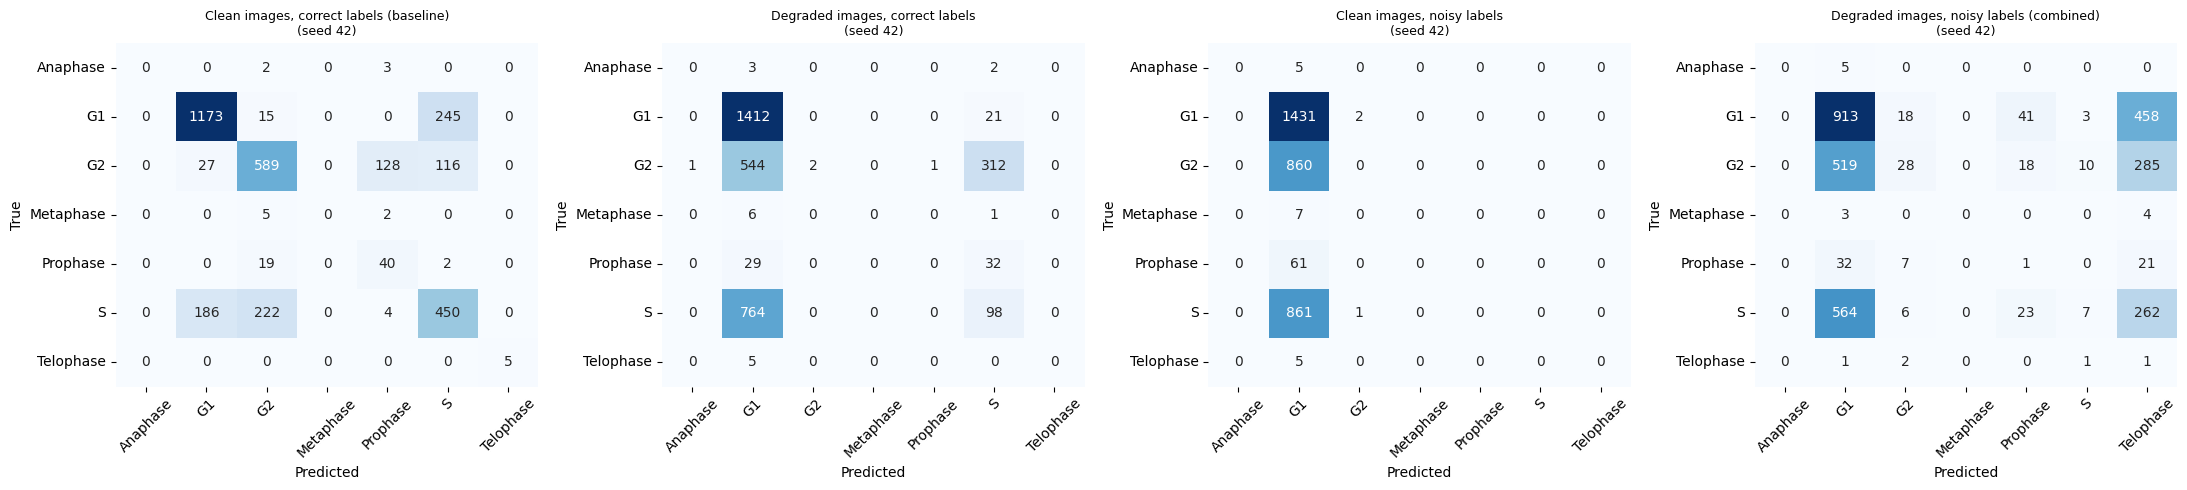

In [22]:
# Confusion matrices, one per condition, for a representative (first) seed
first_seed = CONFIG["seeds"][0]
fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(5.5 * len(CONDITIONS), 5))
if len(CONDITIONS) == 1:
    axes = [axes]
for ax, condition in zip(axes, CONDITIONS):
    r = next(x for x in all_run_results if x["condition_key"] == condition["key"] and x["seed"] == first_seed)
    cm = confusion_matrix(y_test_idx, r["preds"], labels=range(NUM_CLASSES))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    ax.set_title(condition["name"] + f"\n(seed {first_seed})", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


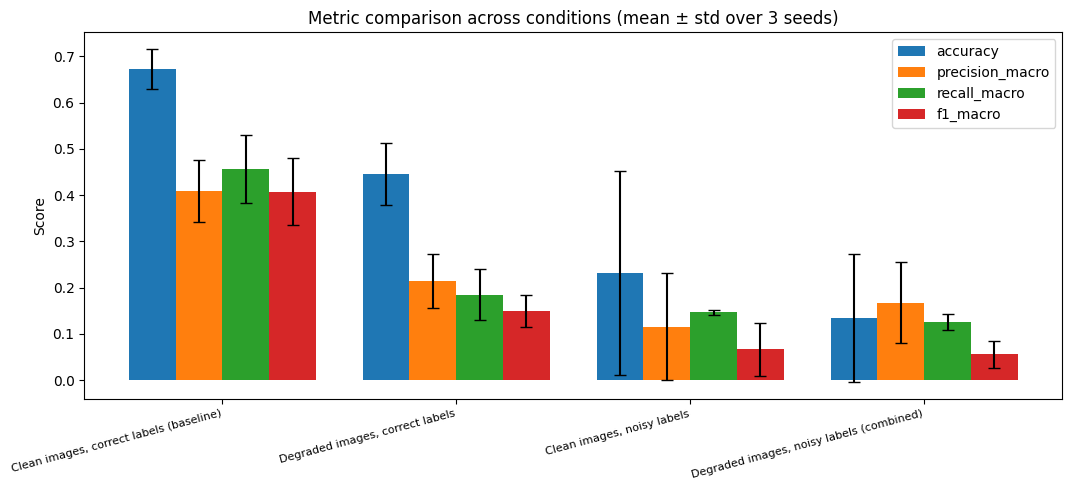

In [23]:
# Metric comparison across conditions, mean +/- std over seeds
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
condition_names = [c["name"] for c in CONDITIONS]
x = np.arange(len(condition_names))
width = 0.2

plt.figure(figsize=(11, 5))
for i, m in enumerate(metrics_to_plot):
    means = [summary_df.loc[name, (m, "mean")] for name in condition_names]
    stds = [summary_df.loc[name, (m, "std")] for name in condition_names]
    plt.bar(x + i * width, means, width, yerr=stds, capsize=4, label=m)
plt.xticks(x + width * 1.5, condition_names, rotation=15, ha="right", fontsize=8)
plt.ylabel("Score")
plt.legend()
plt.title(f"Metric comparison across conditions (mean \u00b1 std over {len(CONFIG['seeds'])} seeds)")
plt.tight_layout()
plt.show()


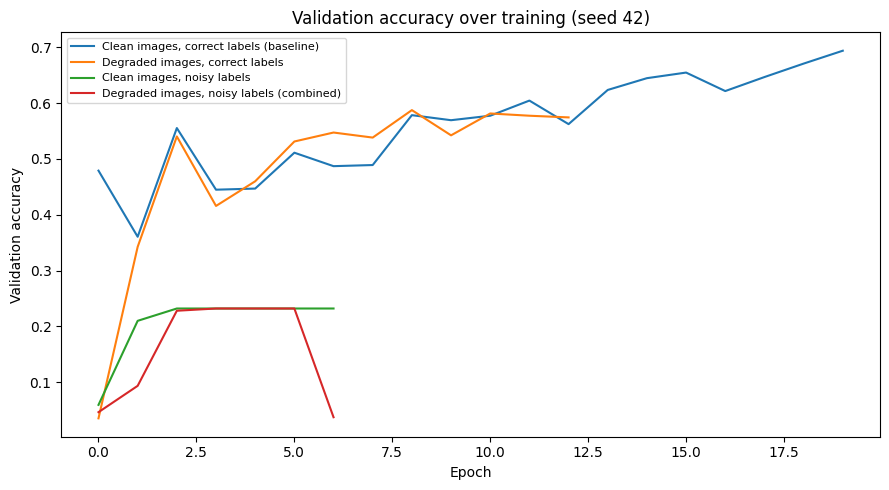

In [24]:
# Validation accuracy over training, one line per condition, for the first seed
plt.figure(figsize=(9, 5))
for condition in CONDITIONS:
    h = histories[f"{condition['key']}__seed{first_seed}"]
    plt.plot(h.history["val_accuracy"], label=condition["name"])
plt.xlabel("Epoch"); plt.ylabel("Validation accuracy")
plt.legend(fontsize=8)
plt.title(f"Validation accuracy over training (seed {first_seed})")
plt.tight_layout()
plt.show()


## 15. Save results

Saves per-run and summary metrics, one classification report per condition (first seed), and the
first-seed model for each condition, so results can be pulled into your report/paper or re-loaded
later.


In [25]:
OUT_DIR = "/content/results"
os.makedirs(OUT_DIR, exist_ok=True)

results_df.to_csv(os.path.join(OUT_DIR, "all_runs.csv"), index=False)
summary_df.to_csv(os.path.join(OUT_DIR, "summary_by_condition.csv"))

def save_classification_report(y_true, preds, class_names, path):
    present_labels = sorted(set(y_true.tolist()) | set(preds.tolist()))
    present_names = [class_names[i] for i in present_labels]
    report = classification_report(y_true, preds, labels=present_labels,
                                    target_names=present_names,
                                    zero_division=0, output_dict=True)
    pd.DataFrame(report).to_csv(path)

for condition in CONDITIONS:
    r = next(x for x in all_run_results if x["condition_key"] == condition["key"] and x["seed"] == first_seed)
    save_classification_report(
        y_test_idx, r["preds"], label_encoder.classes_,
        os.path.join(OUT_DIR, f"classification_report_{condition['key']}_seed{first_seed}.csv")
    )
    models_store[f"{condition['key']}__seed{first_seed}"].save(
        os.path.join(OUT_DIR, f"model_{condition['key']}_seed{first_seed}.keras")
    )

print("Saved to", OUT_DIR)
print(os.listdir(OUT_DIR))

# Optional: zip everything for download
!zip -r -q /content/results.zip {OUT_DIR}
print("\nDownload with: from google.colab import files; files.download('/content/results.zip')")


Saved to /content/results
['model_degraded_noisy_seed42.keras', 'model_clean_correct_seed42.keras', 'summary_by_condition.csv', 'model_clean_noisy_seed42.keras', 'classification_report_degraded_noisy_seed42.csv', 'classification_report_clean_correct_seed42.csv', 'all_runs.csv', 'model_degraded_correct_seed42.keras', 'classification_report_degraded_correct_seed42.csv', 'classification_report_clean_noisy_seed42.csv']

Download with: from google.colab import files; files.download('/content/results.zip')


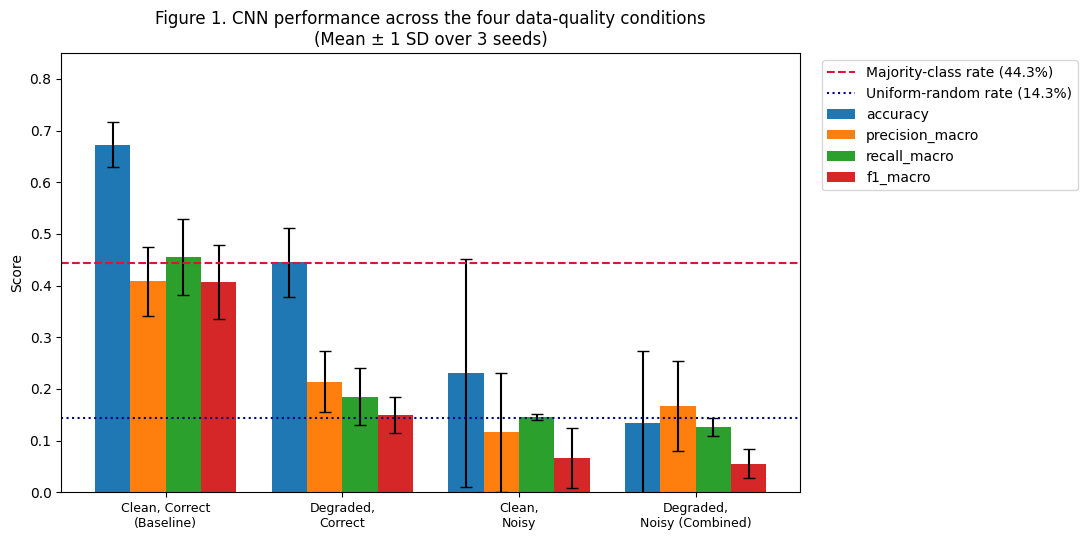

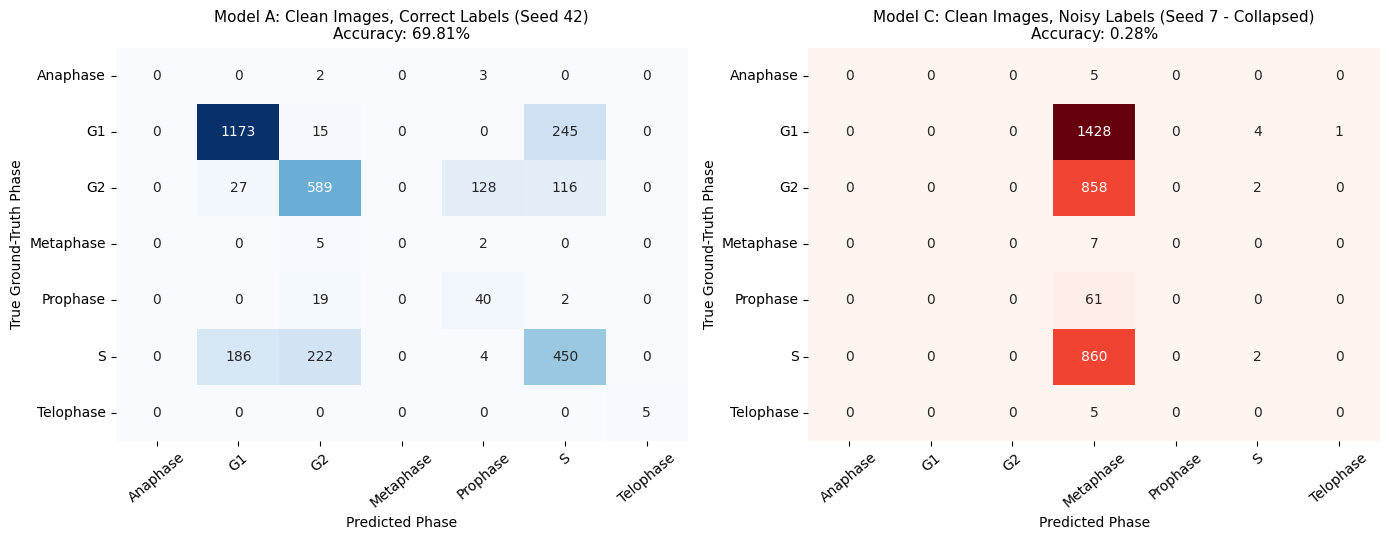

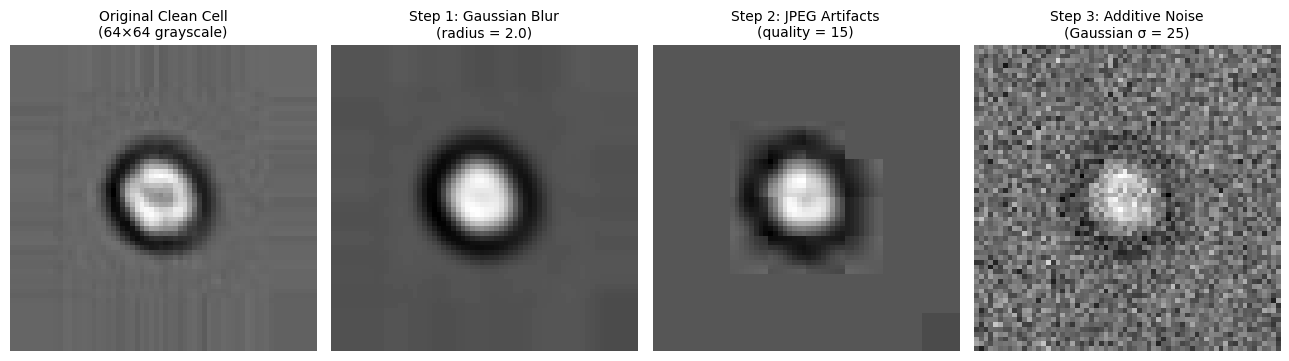

In [26]:
import io
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFilter
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==============================================================================
# 1. UPDATE FIGURE 1: Bar chart with Majority-class and Uniform-random baselines
# ==============================================================================
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
condition_names = [c["name"] for c in CONDITIONS]
x = np.arange(len(condition_names))
width = 0.2

plt.figure(figsize=(11, 5.5))
for i, m in enumerate(metrics_to_plot):
  means = [summary_df.loc[name, (m, "mean")] for name in condition_names]
  stds = [summary_df.loc[name, (m, "std")] for name in condition_names]
  plt.bar(x + i * width, means, width, yerr=stds, capsize=4, label=m)

# Reference lines from Figure 1 caption:
# Dashed line: majority-class rate in test set (1433 / 3233 ≈ 44.3%)
plt.axhline(
    y=0.443,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="Majority-class rate (44.3%)",
)
# Dotted line: uniform random guessing for 7 classes (1/7 ≈ 14.3%)
plt.axhline(
    y=1 / 7,
    color="navy",
    linestyle=":",
    linewidth=1.5,
    label="Uniform-random rate (14.3%)",
)

plt.xticks(
    x + width * 1.5,
    [
        "Clean, Correct\n(Baseline)",
        "Degraded,\nCorrect",
        "Clean,\nNoisy",
        "Degraded,\nNoisy (Combined)",
    ],
    fontsize=9,
)
plt.ylabel("Score")
plt.ylim(0, 0.85)
plt.title(
    "Figure 1. CNN performance across the four data-quality conditions\n(Mean ±"
    f" 1 SD over {len(CONFIG['seeds'])} seeds)"
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig("figure1_performance_with_baselines.png", dpi=300)
plt.show()

# ==============================================================================
# 2. ACTION ITEM (1): Confusion Matrices for Model A and Collapsed Model C (Seed 7)
# ==============================================================================
# Retrieve predictions from all_run_results
res_A_seed42 = next(
    r
    for r in all_run_results
    if r["condition_key"] == "clean_correct" and r["seed"] == 42
)
res_C_seed7 = next(
    r
    for r in all_run_results
    if r["condition_key"] == "clean_noisy" and r["seed"] == 7
)

cm_A = confusion_matrix(
    y_test_idx, res_A_seed42["preds"], labels=range(NUM_CLASSES)
)
cm_C = confusion_matrix(
    y_test_idx, res_C_seed7["preds"], labels=range(NUM_CLASSES)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
classes = label_encoder.classes_

sns.heatmap(
    cm_A,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[0],
    cbar=False,
)
axes[0].set_title(
    "Model A: Clean Images, Correct Labels (Seed 42)\nAccuracy: 69.81%",
    fontsize=11,
)
axes[0].set_xlabel("Predicted Phase")
axes[0].set_ylabel("True Ground-Truth Phase")
axes[0].tick_params(axis="x", rotation=40)

sns.heatmap(
    cm_C,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[1],
    cbar=False,
)
axes[1].set_title(
    "Model C: Clean Images, Noisy Labels (Seed 7 - Collapsed)\nAccuracy: 0.28%",
    fontsize=11,
)
axes[1].set_xlabel("Predicted Phase")
axes[1].set_ylabel("True Ground-Truth Phase")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("figure_confusion_matrix_collapse.png", dpi=300)
plt.show()

# ==============================================================================
# 3. ACTION ITEM (2): Example cell image at each degradation step
# ==============================================================================
# Pick one representative Jurkat cell image from the test set
sample_path = test_df.iloc[0]["filepath"]
orig_arr = load_image(sample_path, CONFIG["img_size"])

# Step 1: Gaussian Blur
img_pil = Image.fromarray(orig_arr)
blur_pil = img_pil.filter(ImageFilter.GaussianBlur(radius=CONFIG["blur_radius"]))
arr_blur = np.array(blur_pil, dtype=np.uint8)

# Step 2: JPEG compression artifacts
buf = io.BytesIO()
blur_pil.save(buf, format="JPEG", quality=CONFIG["jpeg_quality"])
buf.seek(0)
arr_jpeg = np.array(Image.open(buf).convert("L"), dtype=np.float32)

# Step 3: Additive Gaussian Noise (Full composite degradation)
np.random.seed(42)
noise = np.random.normal(0, CONFIG["noise_std"], arr_jpeg.shape)
arr_final = np.clip(arr_jpeg + noise, 0, 255).astype(np.uint8)

steps = [
    (orig_arr, "Original Clean Cell\n(64×64 grayscale)"),
    (arr_blur, f"Step 1: Gaussian Blur\n(radius = {CONFIG['blur_radius']})"),
    (
        arr_jpeg.astype(np.uint8),
        f"Step 2: JPEG Artifacts\n(quality = {CONFIG['jpeg_quality']})",
    ),
    (
        arr_final,
        f"Step 3: Additive Noise\n(Gaussian σ = {CONFIG['noise_std']})",
    ),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, (img_data, title) in zip(axes, steps):
  ax.imshow(img_data, cmap="gray")
  ax.set_title(title, fontsize=10)
  ax.axis("off")

plt.tight_layout()
plt.savefig("figure_degradation_steps.png", dpi=300)
plt.show()

## 16. Notes for your write-up

- **Design.** The four conditions isolate image degradation and label noise both independently and
  combined, so the paper can attribute an observed effect to one factor, the other, or their
  interaction, rather than only reporting their bundled effect.
- **Leakage control.** Splitting is done at the physical-cell level (Section 4 dedup + Section 6
  split), after which the notebook verifies zero cell-ID overlap between train and test.
- **Class imbalance.** Rather than an equal-N split, this version keeps proportionally more data per
  class (capped for compute, not for balance) and uses class-weighted loss during training. Report
  per-class precision/recall (Section 15's classification reports) alongside aggregate accuracy,
  since accuracy alone is misleading on imbalanced biological data — this was true in earlier drafts
  and is still worth checking here.
- **Statistical support.** Because each condition is repeated across `CONFIG["seeds"]`, you can
  report mean ± std (already computed in Section 13) and, if your venue expects it, a simple
  significance test (e.g. a paired t-test or Wilcoxon signed-rank test across seeds) between
  conditions on the metric of interest.
- **Rare classes.** Metaphase, Telophase, and Anaphase are still rare in absolute terms even after
  the split changes here; treat their per-class numbers as indicative rather than definitive, and
  say so explicitly in the paper.
- **Scaling up further.** Increase `CONFIG["max_train_per_class"]`, `CONFIG["img_size"]`, or the
  number of `CONFIG["seeds"]` for a stronger final run once the pipeline has been validated at the
  current settings. Using the full deduplicated dataset (all ~32,266 cells) and a larger image size
  would bring this closer to the published DeepFlow benchmark for this dataset, which used the full
  dataset and multi-channel input.
- **Training stability.** Gradient clipping, He initialization, label smoothing, capped class
  weights, and a `ReduceLROnPlateau` scheduler are all in place specifically to prevent the kind of
  collapse or divergence that can occur when class-weighted loss meets mislabeled examples in the
  noisy-label conditions. If you still observe a run collapsing (near-zero accuracy, exploding
  `val_loss`), the per-run `all_runs.csv` records each run's `max_class_weight_applied`, which is the
  first thing to check.
- **Channel choice.** This notebook uses one image per cell, deterministically preferring the lowest
  channel number, because there is no documentation in this pipeline mapping `Ch3`/`Ch4`/`Ch6` to a
  specific imaging modality. If you can obtain that mapping (e.g. from BBBC048's documentation or
  metadata), using the fluorescence/DNA-content channel specifically — or stacking multiple channels
  as multi-channel input — is a natural next step and is likely to improve absolute performance
  substantially.
